In [1]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as stats 
from pandas.plotting import parallel_coordinates 
from statsmodels.graphics.mosaicplot import mosaic 
import math 
from datetime import datetime

In [9]:
teste1 = pd.read_excel('corr_teste1.xlsx', decimal = ',')
teste1.columns = teste1.iloc[0]
teste1.drop(teste1.index[0], axis = 0, inplace = True )
teste1.reset_index(drop = True, inplace = True)
variaveis = ['vacuo ','temp ','vel ','umidade','acidez ','AR']
for i in variaveis:
    teste1[i] = teste1[i].astype('float')



In [20]:
teste2 = pd.read_excel('corr_teste2.xlsx', decimal = ',')
teste2.columns = teste2.iloc[0]
teste2.drop(teste2.index[0], axis = 0, inplace = True )
teste2.reset_index(drop = True, inplace = True)
variaveis = ['vacuo ','temp ','vel ','umidade','acidez ','AR']
for i in variaveis:
    teste2[i] = teste2[i].astype('float')

In [21]:
index1 = teste1[teste1['umidade']==317].index
index2 = teste2[teste2['umidade']==317].index
teste1 = teste1.drop(teste1.index[index1], axis = 0)
teste2 = teste2.drop(teste2.index[index2], axis = 0)

In [12]:
def matriz_corr(teste1, variaveis):
    analise1 = teste1[variaveis]
    figura, axes = plt.subplots(len(variaveis),len(variaveis), figsize = (15,15))
    correlacao = analise1.corr()
    for i in range(0,len(variaveis)):
        for j in range(0,len(variaveis)):
            
            if i>j:
                sns.regplot(ax = axes[i,j], data = teste1, x = teste1[variaveis[j]], y = teste1[variaveis[i]])
                
            elif i<j:
                axes[i,j].text(0.3,0.5,correlacao.iloc[j,i].round(3))
                
            else:
                sns.histplot(ax = axes[i,j], data = teste1, x = variaveis[i], kde = True)
                axes[i,j].set(xticks = ([]), yticks = ([]))

            if i < len(variaveis)-1:
                axes[i,j].set(xticks = ([]), xlabel = '')
            if j > 0 :
                axes[i,j].set(yticks = ([]), ylabel = '')
    
    return figura

In [ ]:
analise1 = teste1[variaveis]
descritivo = analise1.describe()
fig, axes = plt.subplots(len(variaveis),3, figsize = (40,55), width_ratios=[1,0.6,0.6])
for i in range(0,len(variaveis)):
    sns.boxplot(ax = axes[i,0], data = teste1, x = 'produto ', y = variaveis[i])
    axes[i,0].grid(axis = 'x')
    
    dados = teste1.groupby('produto ')[variaveis[i]].describe()
    descr = axes[i,1].table(cellText = dados.values.round(2),rowLabels=dados.index,colLabels= dados.columns , bbox = [0,0,1,1])
    descr.auto_set_font_size(False)
    descr.set_fontsize(10)
    axes[i,1].set(xticks = ([]), yticks = ([]))

    sns.histplot(ax = axes[i,2], data = teste1, x = variaveis[i], bins = 30, alpha = 0.5, kde = True )

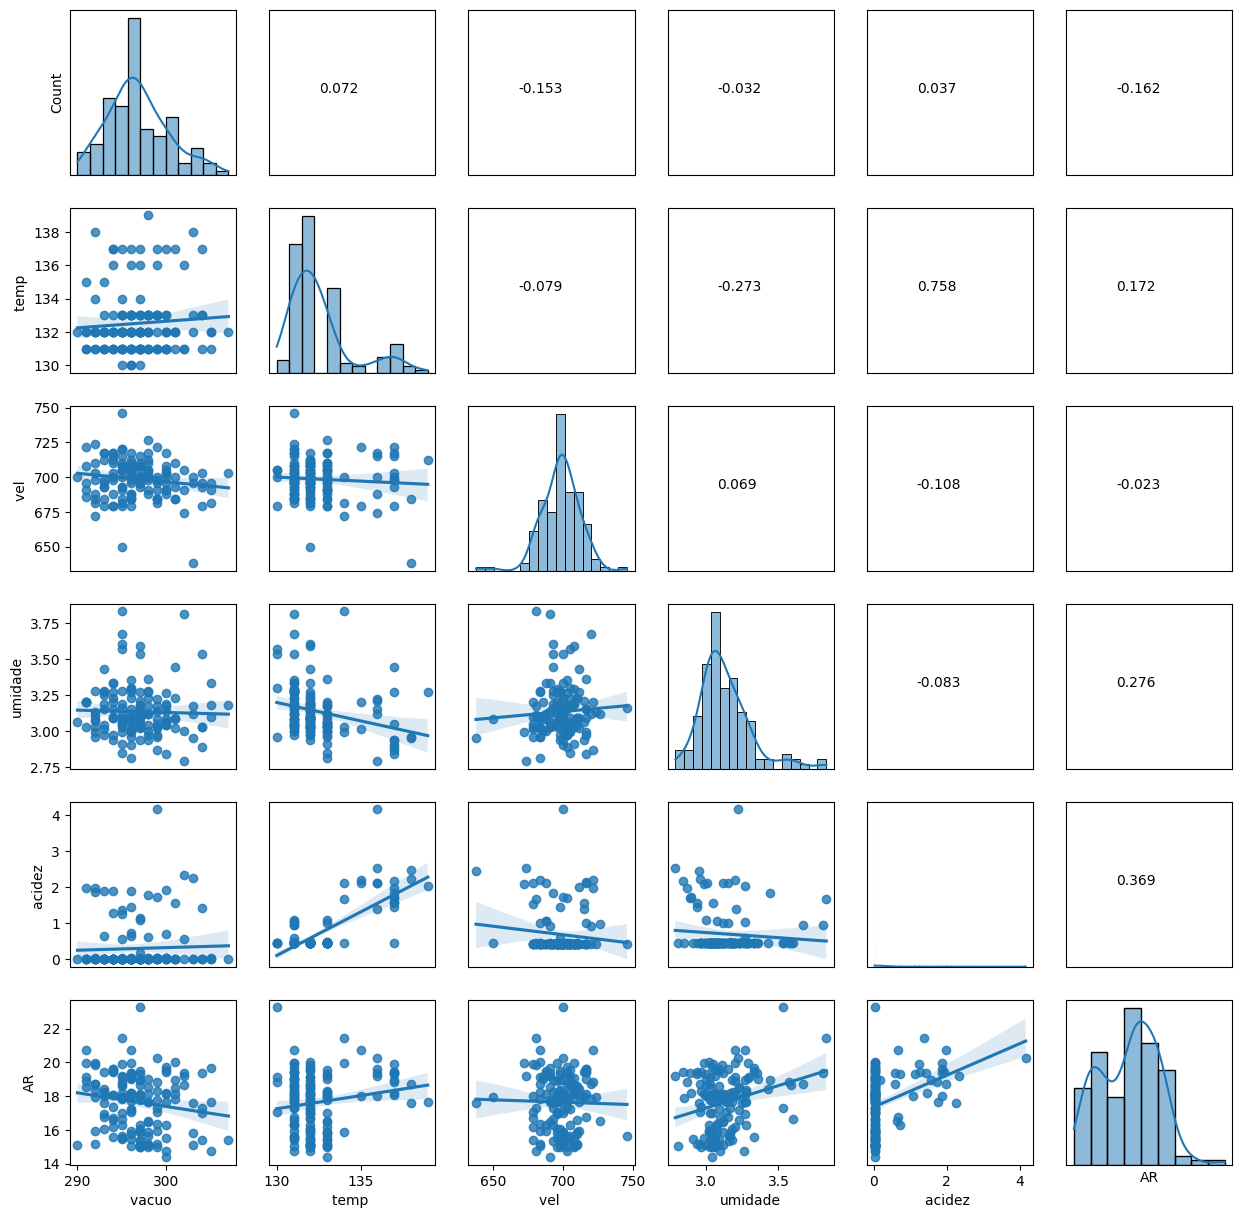

In [22]:
figura = matriz_corr(teste1,variaveis)

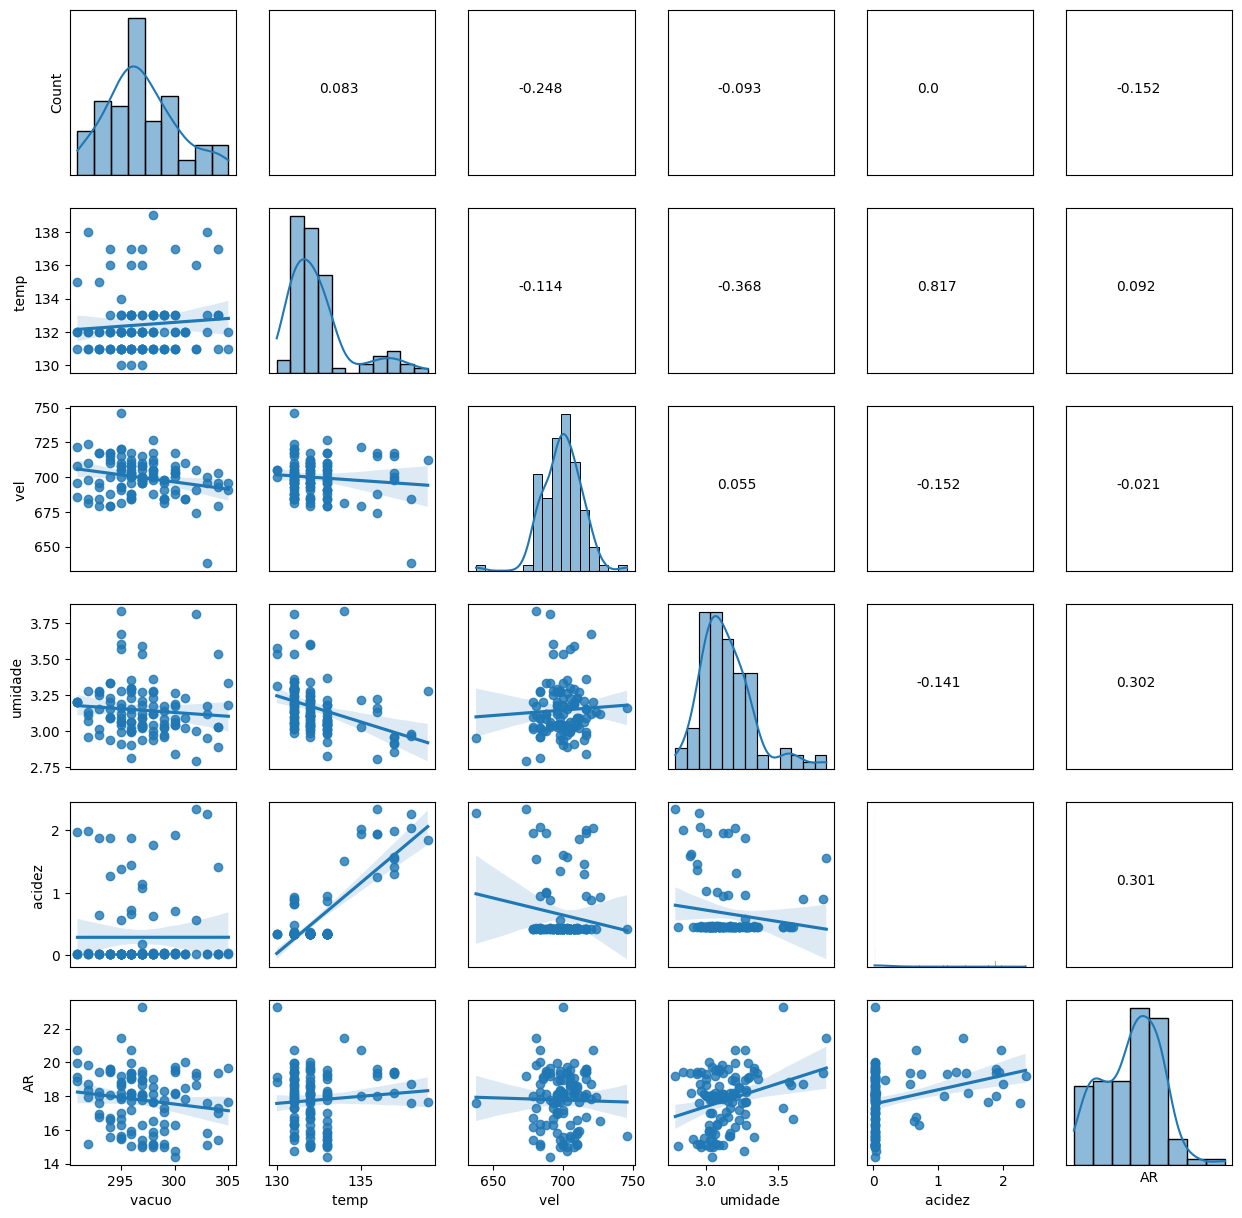

In [23]:
figura = matriz_corr(teste2,lista)